# LLAMAS RSS → 1D Spectrum

## Setup (paths, config)

In [ ]:
# f = 'LLAMAS_2026-01-07_01-16-24.1_SCI22' # standard
# f = 'LLAMAS_2026-01-07_01-25-43.5_SCI22' # J0313
# f = 'LLAMAS_2026-01-07_01-31-59.8_SCI22' # J0313
f = 'LLAMAS_2025-12-14_04-12-57.9_SCI22' # field_19
# f = 'LLAMAS_2025-12-14_07-41-38.0_SCI22'
# f = 'LLAMAS_2025-12-14_01-30-00.7_SCI22' # standard
# ex_dir = '/data/llamas/reduced/2026-01-06/extractions/'
ex_dir = '/data/llamas/reduced/2025-12-13/extractions/'
# f = 'LLAMAS_2024-11-30T08_22_09.466' # ATLASJ1013-4516
# ex_dir = '/data/llamas/reduced/2024-11-29/extractions/'

fp = {
    "blue":  f"{ex_dir}{f}_extract_RSS_blue.fits",
    "green": f"{ex_dir}{f}_extract_RSS_green.fits",
    "red":   f"{ex_dir}{f}_extract_RSS_red.fits",
}

# Fit config
BAND_FIT = "blue" # "red"
X_GUESS, Y_GUESS = 24, 24
HALF_SIZE = 3.0

# Image/grid config (for the fit + plotting)
NX, NY = 400, 400
SMOOTH_SIGMA = 5.0

# Coadd config
SIGMA_CLIP = 3.0  # applied inside weighted_coadd

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from utils.geometry import (
    get_fibermap_lut,
    select_fiber_aperture_and_sky_annulus,
    fit_whitelight_center_2dgauss
)
from utils.whitelight import (
    build_whitelight_dict,
    normalize_whitelight_per_bench,
    interpolate_whitelight_to_grid,   
)
from utils.io import load_llamas_spectrum
from utils.coadd import coadd_obj_sky  
from utils.plotting import (
    plot_whitelight_extraction_diagnostic,
    plot_obj_sky_and_subtracted,
    plot_coadd_diagnostic,
)

from utils.paths import plots_path

bands = ["blue", "green", "red"]

## Load LUT + whitelight

In [3]:
fibermap_lut = get_fibermap_lut()

whitelight = build_whitelight_dict(fp["blue"], fp["green"], fp["red"], fibermap_lut)
whitelight = normalize_whitelight_per_bench(whitelight, cmap_name="magma")

print("Bands:", list(whitelight.keys()))
for b in bands:
    print(b, "n_fibers =", len(whitelight[b]["xpos"]))

Bands: ['blue', 'green', 'red']
blue n_fibers = 2389
green n_fibers = 2389
red n_fibers = 2389


## Quick whitelight scatter

Saved: /home/echickle/projects/llamas-quicklook/plots/LLAMAS_2025-12-14_07-41-38.0_SCI22_whitelight_scatter.png


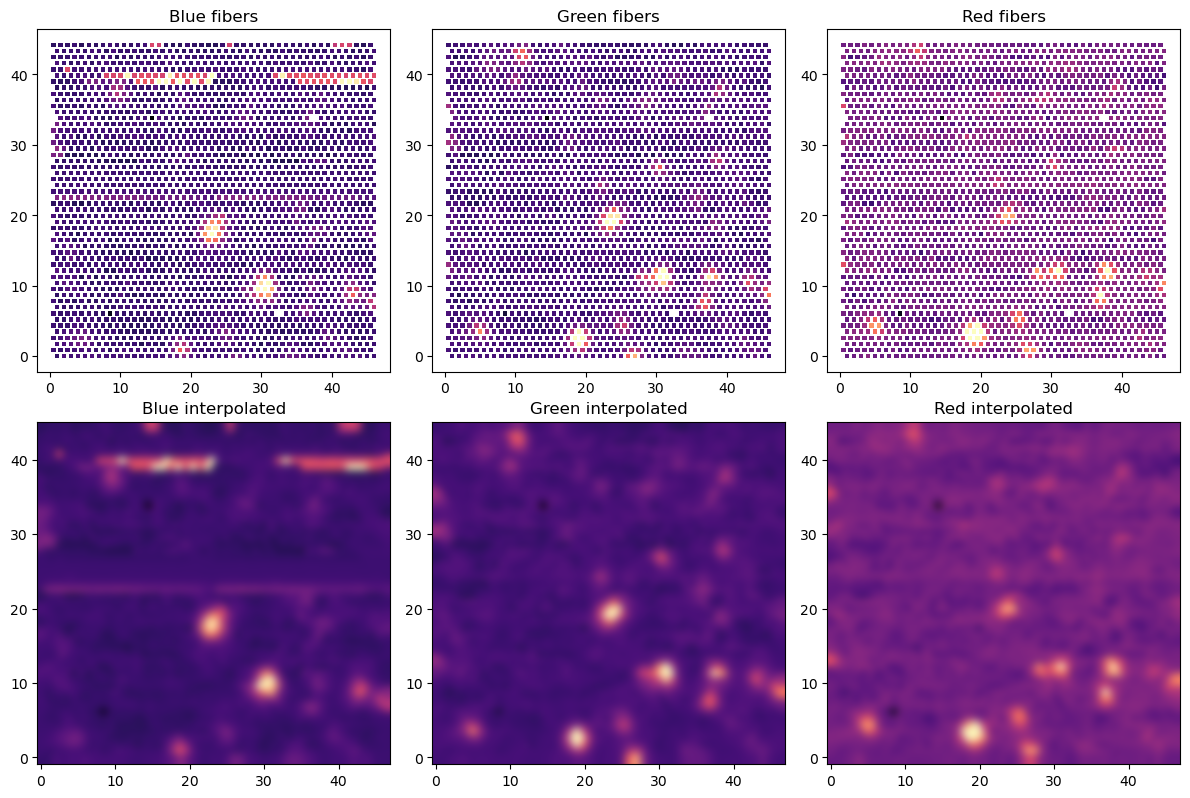

In [4]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(12, 8))
for c, band in enumerate(bands):
    xpos = whitelight[band]["xpos"]
    ypos = whitelight[band]["ypos"]
    colors = whitelight[band]["colors"]

    ax[0, c].scatter(xpos, ypos, facecolors=colors, edgecolors="none", marker="s", s=10)
    ax[0, c].set_aspect("equal")
    ax[0, c].set_title(f"{band.capitalize()} fibers")

    img, extent, Xg, Yg = interpolate_whitelight_to_grid(whitelight, band, nx=400, ny=400, sigma=5.0)
    ax[1, c].imshow(img, extent=extent, origin="lower", aspect="equal")
    ax[1, c].set_title(f"{band.capitalize()} interpolated")

plt.tight_layout()

# Save figure
out_path = plots_path(f"{f}_whitelight_scatter.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Saved: {out_path}")

plt.show()

## Fit center with 2D Gaussian on a patch

Fit center (blue): x=27.0000, y=22.5058
Setting R_OBJ_MAX = 6.1761 based on fit widths sx=4.2414, sy=0.6995
Saved: /home/echickle/projects/llamas-quicklook/plots/LLAMAS_2025-12-14_07-41-38.0_SCI22_2dgauss_fit_blue.png


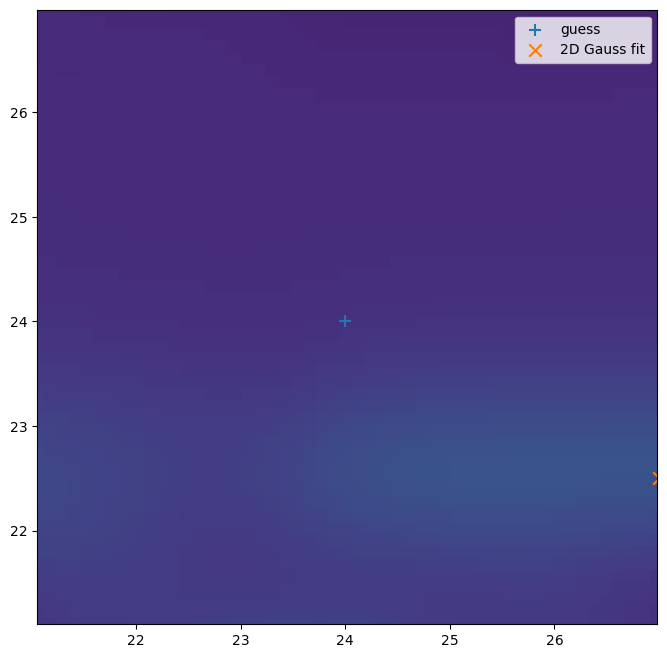

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
fit = fit_whitelight_center_2dgauss(
    whitelight,
    band=BAND_FIT,
    x_guess=X_GUESS,
    y_guess=Y_GUESS,
    half_size=HALF_SIZE,
    nx=NX,
    ny=NY,
    smooth_sigma=SMOOTH_SIGMA,
    make_plot=True,
    ax=ax,
)

x_fit, y_fit = fit["x_fit"], fit["y_fit"]
print(f"Fit center ({BAND_FIT}): x={x_fit:.4f}, y={y_fit:.4f}")

sx_fit, sy_fit = fit["sx_fit"], fit["sy_fit"]
R_OBJ_MAX = 2.5 * np.mean([sx_fit, sy_fit])
R_SKY_MIN = 5 * np.mean([sx_fit, sy_fit])
R_SKY_MAX = 15 * np.mean([sx_fit, sy_fit])
print(f"Setting R_OBJ_MAX = {R_OBJ_MAX:.4f} based on fit widths sx={sx_fit:.4f}, sy={sy_fit:.4f}")

# Save figure
out_path = plots_path(f"{f}_2dgauss_fit_{BAND_FIT}.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Saved: {out_path}")

plt.show()

## Load spectra for this exposure

In [6]:
spec_map = {band: load_llamas_spectrum(fp[band]) for band in bands}

for band in bands:
    s = spec_map[band]
    print(band, "flux shape:", s["flux"].shape, "wave shape:", s["wave"].shape)


blue flux shape: (2389, 2048) wave shape: (2389, 2048)
green flux shape: (2389, 2048) wave shape: (2389, 2048)
red flux shape: (2389, 2048) wave shape: (2389, 2048)


## Seelct obj/sky indices from fitted center

In [7]:
x0, y0 = x_fit, y_fit

selection = {}
for band in bands:
    xpos = whitelight[band]['xpos']
    ypos = whitelight[band]['ypos']
    bench = whitelight[band]['bench']
    obj_inds, sky_inds, bench0, center_ind = select_fiber_aperture_and_sky_annulus(
        xpos, ypos, bench,
        x0, y0,
        r_obj_max=R_OBJ_MAX,
        r_sky_min=R_SKY_MIN,
        r_sky_max=R_SKY_MAX,
    )
    selection[band] = {
        "obj_inds": obj_inds,
        "sky_inds": sky_inds,
        "bench0": bench0,
        "center_ind": center_ind,
    }
    print(f"{band}: bench={bench0}  obj={len(obj_inds)}  sky={len(sky_inds)}")


blue: bench=4A  obj=74  sky=143
green: bench=4A  obj=74  sky=143
red: bench=4A  obj=74  sky=143


## Plot image patch + fiber scatter + obj/sky overlay

Saved: /home/echickle/projects/llamas-quicklook/plots/LLAMAS_2025-12-14_07-41-38.0_SCI22_extraction_diagnostic.png


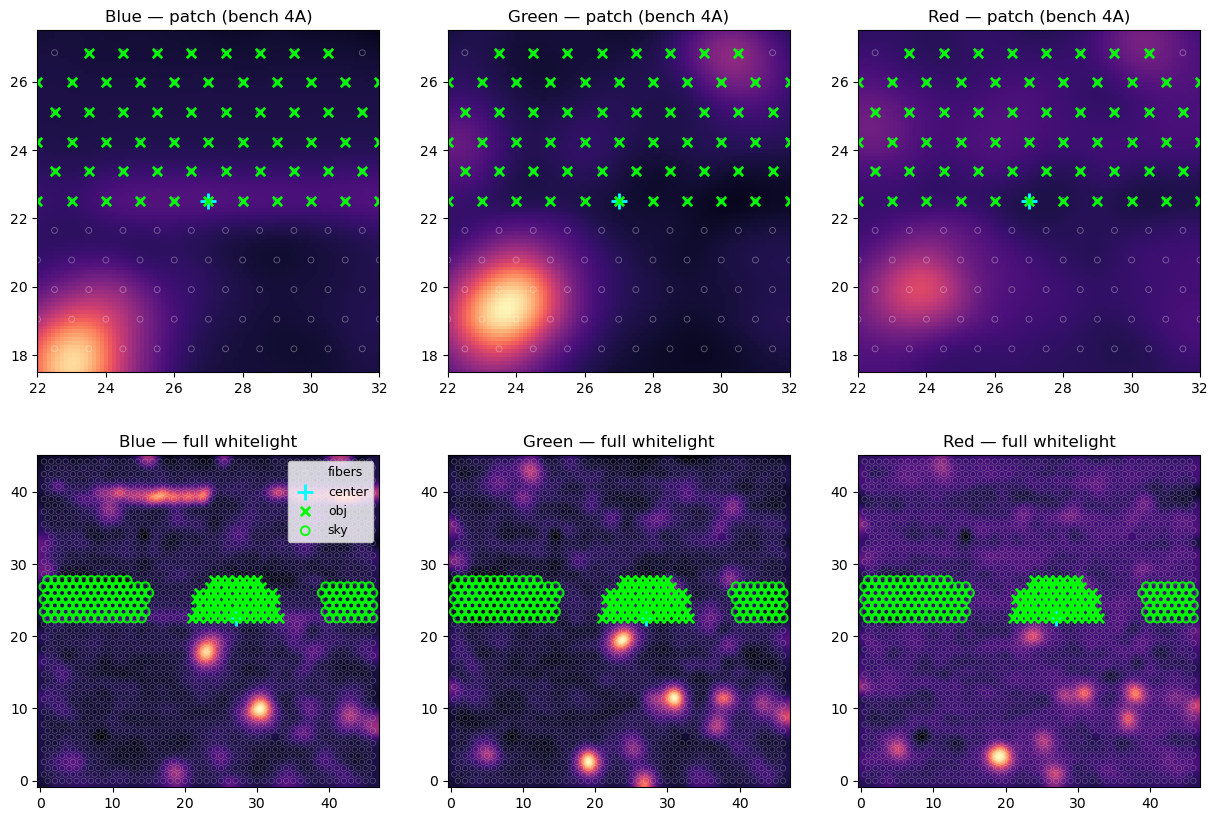

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

plot_whitelight_extraction_diagnostic(
    whitelight,
    selection,
    x0,
    y0,
    fig=fig,
    axs=axs,
)

# Save figure
out_path = plots_path(f"{f}_extraction_diagnostic.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Saved: {out_path}")

plt.show()

## Extract aperture-coadded spectrum

In [9]:
coadds = {}

for band in bands:
    obj_inds = selection[band]["obj_inds"]
    sky_inds = selection[band]["sky_inds"]

    coadds[band] = coadd_obj_sky(
        spec_map[band],
        obj_inds=obj_inds,
        sky_inds=sky_inds,
        sigma_clip=SIGMA_CLIP,
    )
    # keep indices for plotting convenience
    coadds[band]["obj_inds"] = obj_inds
    coadds[band]["sky_inds"] = sky_inds


## Plot obj, sky, and sky-subtracted spectra

Saved: /home/echickle/projects/llamas-quicklook/plots/LLAMAS_2025-12-14_07-41-38.0_SCI22_obj_sky.png


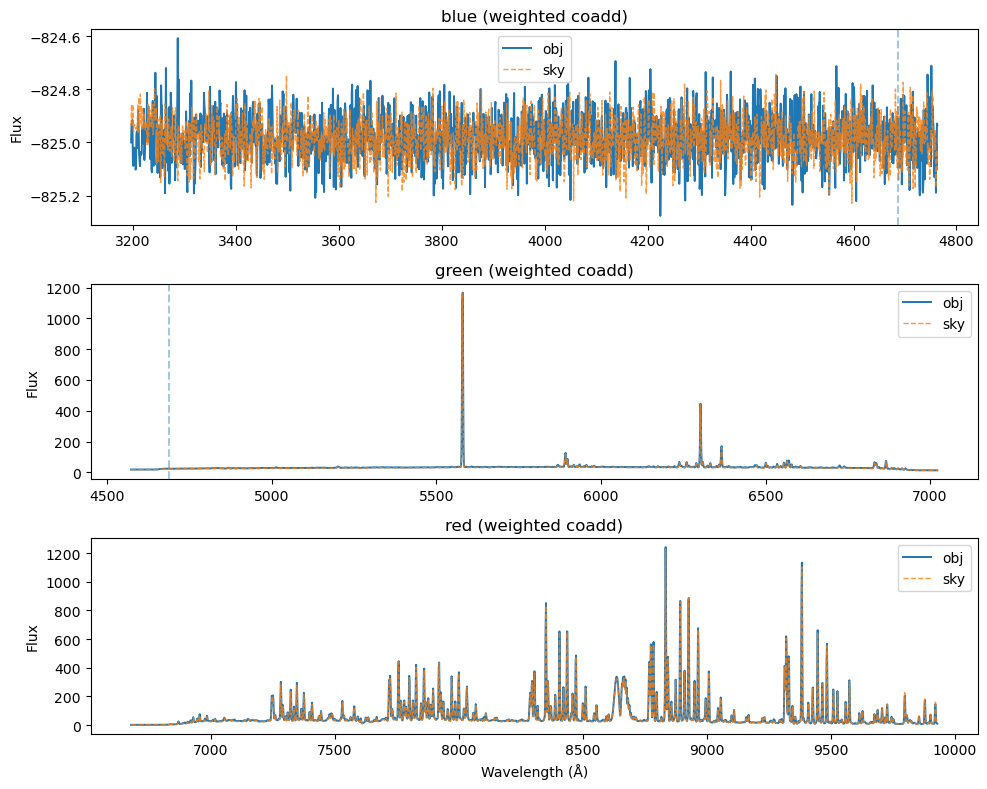

Saved: /home/echickle/projects/llamas-quicklook/plots/LLAMAS_2025-12-14_07-41-38.0_SCI22_obj_sky_subtracted.png


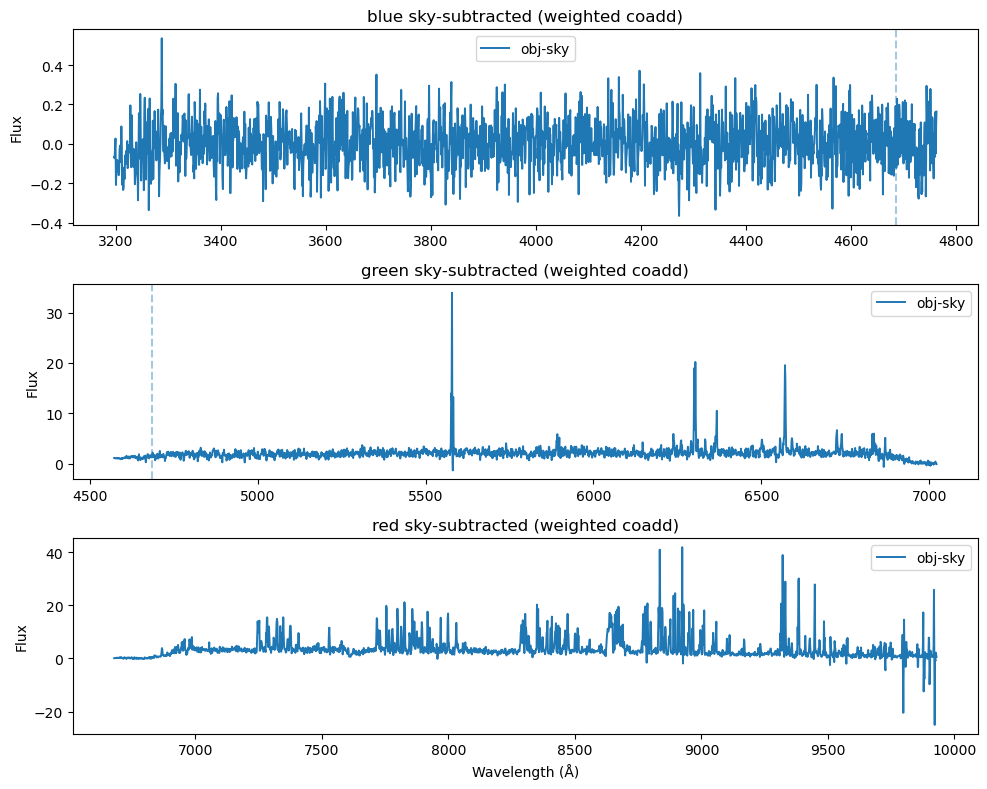

In [10]:
plot_obj_sky_and_subtracted(
    coadds, 
    title_suffix=" (weighted coadd)",
    save_path=plots_path(f"{f}_obj_sky.png")
)